# Bayesian Optimisation - Capstone
Iterative GP-based optimisation across 8 black-box functions.
Config is driven by `config/params.csv` — update that file to change kernel, acquisition function, transforms, etc.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

print('Libraries loaded OK')

Libraries loaded OK


## 2. Configuration

In [2]:
# ── USER SETTINGS ──────────────────────────────────────────────
from pathlib import Path

# Resolve the repository root by walking up until a 'data' folder is found,
# so the notebook runs from notebooks/, the repo root, or a fresh clone.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())

CURRENT_WEEK   = 13                       # Final week of the campaign
RUN_FUNCTIONS  = 'all'                    # 'all' or a list e.g. [1, 3, 6]
DATA_DIR       = str(ROOT / 'data')       # function_N.csv files (all 13 weeks)
CONFIG_PATH    = str(ROOT / 'config' / 'params.csv')
RESULTS_DIR    = str(ROOT / 'runs' / f'week_{CURRENT_WEEK:02d}')
FIGURES_DIR    = str(ROOT / 'figures')
N_RESTARTS     = 50         # GP optimiser restarts (higher = more reliable, slower)
N_CANDIDATES   = 5000       # Base candidates (scaled by dim in run_optimisation: 5k/10k/20k for 2-3D/4-5D/6D+)
BOUNDS         = (0.0, 0.999999)   # Input bounds per capstone FAQ
# ───────────────────────────────────────────────────────────────

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Week {CURRENT_WEEK} | Data → {DATA_DIR}')
print(f'Week {CURRENT_WEEK} | Results → {RESULTS_DIR}')


Week 13 | Data → /home/claude/repo/data
Week 13 | Results → /home/claude/repo/runs/week_13


## 3. Core Functions

In [3]:
# ── DATA LOADING ───────────────────────────────────────────────

def load_function_data(fn, data_dir=DATA_DIR):
    """Load CSV for function fn. Returns X (n x d) and y (n,)."""
    path = os.path.join(data_dir, f'function_{fn}.csv')
    df = pd.read_csv(path)
    X = df.drop(columns='output').values
    y = df['output'].values
    return X, y


def load_function_df(fn, data_dir=DATA_DIR):
    """Load CSV for function fn as a DataFrame (x1..xd plus 'output')."""
    return pd.read_csv(os.path.join(data_dir, f'function_{fn}.csv'))


def append_result(fn, x_new, y_new, data_dir=DATA_DIR):
    """Append a new (x, y) observation to the function's CSV."""
    path = os.path.join(data_dir, f'function_{fn}.csv')
    df = pd.read_csv(path)
    d = len(df.columns) - 1  # number of input dims
    row = {f'x{i+1}': x_new[i] for i in range(d)}
    row['output'] = y_new
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(path, index=False)
    print(f'  Appended result to {path}')


def get_fn_config(fn, run_label='matern_ard_ei'):
    """
    Return the params.csv row for a function, so diagnostics and
    visualisations use the SAME output transform as the submission runs
    (f1 and f5 are fitted in log10 space; f1 floors negatives at -300).
    """
    rows = params[(params['fn'] == fn) & (params['week'] == CURRENT_WEEK)]
    if rows.empty:
        rows = params[params['fn'] == fn]
    match = rows[rows['run_label'] == run_label]
    return (match.iloc[0] if not match.empty else rows.iloc[0])


print('Data functions defined')

Data functions defined


In [4]:
# ── OUTPUT TRANSFORMS ──────────────────────────────────────────

def transform_outputs(y, log_transform, neg_floor=None):
    """
    Apply output transform before GP fitting.
    log_transform: if True, apply log10 transform (for extreme-range functions)
    neg_floor: if set (e.g. -300), floor negatives to this value in log space
               if None, keep negatives as-is (normal-scale functions)
    """
    # Accept either explicit flags or a config row/dict (used by the
    # diagnostic and visualisation sections).
    if hasattr(log_transform, 'get') or hasattr(log_transform, 'index'):
        cfg = log_transform
        log_transform = str(cfg['log_transform']).lower() == 'true'
        nf = cfg.get('neg_floor') if hasattr(cfg, 'get') else cfg['neg_floor']
        neg_floor = None if str(nf) in ('', 'nan', 'None') else float(nf)

    if not log_transform:
        return y.copy()
    
    y_t = np.where(y > 0, np.log10(y), neg_floor if neg_floor is not None else np.log10(np.abs(y) + 1e-300))
    return y_t


print('Transform functions defined')

Transform functions defined


In [5]:
# ── KERNEL BUILDER ─────────────────────────────────────────────

def build_kernel(d, kernel_type, ARD, nu=2.5, fn=None):
    """
    Build sklearn kernel.
    d          : input dimensionality
    kernel_type: 'RBF' or 'Matern'
    ARD        : if True, use per-dimension length scales
    nu         : Matern smoothness parameter (0.5, 1.5, 2.5)
    """
    ls = np.ones(d) if ARD else 1.0
    if fn == 8:
        ls_bounds = (1e-3, 10.0)      # cap=10 for f8
    elif fn == 1:
        ls_bounds = (0.05, 5.0)       # raised lower bound — prevents wild extrapolation from overfitting
    else:
        ls_bounds = (1e-3, 5.0)       # cap=5 elsewhere
    
    if kernel_type == 'RBF':
        base = RBF(length_scale=ls, length_scale_bounds=ls_bounds)
    elif kernel_type == 'Matern':
        base = Matern(length_scale=ls, length_scale_bounds=ls_bounds, nu=nu)
    else:
        raise ValueError(f'Unknown kernel: {kernel_type}. Use RBF or Matern.')
    
    return C(1.0, (1e-3, 1e3)) * base + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))


print('Kernel builder defined')

Kernel builder defined


In [6]:
# ── ACQUISITION FUNCTIONS ──────────────────────────────────────

def expected_improvement(X_cand, gp, y_best, xi=0.01):
    """EI acquisition. Higher = more promising candidate."""
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return np.maximum(ei, 0)

def upper_confidence_bound(X_cand, gp, kappa=1.5):
    """UCB acquisition. Higher = more promising candidate."""
    """ updated from 2.576 to 1.5 as of week 3 """
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def optimise_acquisition(acq_fn, gp, y_best, d, n_candidates=N_CANDIDATES, 
                         bounds=BOUNDS, n_local=10):
    """Maximise acquisition function via random search + local refinement."""
    from scipy.optimize import minimize

    # Sobol sequence for better space coverage vs pure random (esp. high-D)
    try:
        from scipy.stats import qmc
        sampler = qmc.Sobol(d=d, scramble=True)
        X_cand  = qmc.scale(sampler.random(n_candidates),
                            bounds[0], bounds[1])
    except Exception:
        X_cand = np.random.uniform(bounds[0], bounds[1], size=(n_candidates, d))

    if acq_fn == 'EI':
        scores = expected_improvement(X_cand, gp, y_best)
    elif acq_fn == 'UCB':
        scores = upper_confidence_bound(X_cand, gp)
    else:
        raise ValueError(f'Unknown acquisition function: {acq_fn}. Use EI or UCB.')

    # Refine from top-N candidates with gradient-based local search
    top_idx = np.argsort(scores)[-n_local:]
    scipy_bounds = [(bounds[0], bounds[1])] * d

    def neg_acq(x):
        x = np.clip(x, bounds[0], bounds[1])
        if acq_fn == 'EI':
            return -expected_improvement(x.reshape(1, -1), gp, y_best)[0]
        else:
            return -upper_confidence_bound(x.reshape(1, -1), gp)[0]

    best_x, best_score = X_cand[top_idx[-1]], scores[top_idx[-1]]
    for idx in top_idx:
        res = minimize(neg_acq, X_cand[idx], method='L-BFGS-B', bounds=scipy_bounds,
                       options={'maxiter': 200, 'ftol': 1e-9})
        if -res.fun > best_score:
            best_score = -res.fun
            best_x = np.clip(res.x, bounds[0], bounds[1])

    return best_x


print('Acquisition functions defined')

Acquisition functions defined


In [7]:
# ── MAIN OPTIMISER ─────────────────────────────────────────────

def run_optimisation(cfg):
    """
    Run one optimisation for a single (function, config) row.
    Returns a dict of results.
    """
    fn          = int(cfg['fn'])
    run_label   = cfg['run_label']
    kernel_type = cfg['kernel']
    nu          = float(cfg['nu']) if str(cfg['nu']) not in ('', 'nan') else 2.5
    ARD         = str(cfg['ARD']).lower() == 'true'
    acq_fn      = cfg['acq_fn']
    log_tr      = str(cfg['log_transform']).lower() == 'true'
    neg_floor   = float(cfg['neg_floor']) if str(cfg['neg_floor']) not in ('', 'nan') else None
    noise       = float(cfg['noise'])
    
    print(f'\n  fn={fn} | {run_label} | {kernel_type} | ARD={ARD} | {acq_fn} | log={log_tr}')
    
    # Load data
    X, y = load_function_data(fn)
    d = X.shape[1]
    
    # Transform outputs
    y_t = transform_outputs(y, log_tr, neg_floor)
    y_best = np.max(y_t)
    
    # Build and fit GP
    kernel = build_kernel(d, kernel_type, ARD, nu, fn=fn)
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise,
        n_restarts_optimizer=N_RESTARTS,
        normalize_y=True
    )
    gp.fit(X, y_t)
    
    # Find best candidate
    # Scale candidates by dimensionality for better acquisition surface coverage
    n_cand = 5_000 if d <= 3 else (10_000 if d <= 5 else 20_000)
    x_next = optimise_acquisition(acq_fn, gp, y_best, d, n_candidates=n_cand)
    mu_pred, sigma_pred = gp.predict(x_next.reshape(1, -1), return_std=True)
    
    # Format submission string
    submission = '-'.join([f'{v:.6f}' for v in x_next])
    
    # ARD length scales for diagnostics
    try:
        ls_vals = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
        ls_str  = '-'.join([f'{v:.6f}' for v in ls_vals])  # numeric dash-separated for CSV
        ls_disp = ', '.join([f'x{i+1}:{v:.3f}' for i, v in enumerate(ls_vals)])
    except:
        ls_vals = np.array([])
        ls_str  = 'N/A'
        ls_disp = 'N/A'
    
    print(f'    → Recommendation: {submission}')
    print(f'    → GP pred: μ={mu_pred[0]:.4f}, σ={sigma_pred[0]:.4f}')
    print(f'    → Length scales: {ls_disp}')
    print(f'    → Log marginal likelihood: {gp.log_marginal_likelihood_value_:.3f}')
    
    return {
        'week': cfg['week'],
        'fn': fn,
        'run_label': run_label,
        'kernel': kernel_type,
        'ARD': ARD,
        'acq_fn': acq_fn,
        'log_transform': log_tr,
        'n_obs': len(y),
        'current_best': float(np.max(y)),
        'recommendation': submission,
        'gp_mu': float(mu_pred[0]),
        'gp_sigma': float(sigma_pred[0]),
        'log_marginal_likelihood': float(gp.log_marginal_likelihood_value_),
        'length_scales': ls_str,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }


print('Main optimiser defined')

Main optimiser defined


## 4. Run Optimisation

In [8]:
# Load config and filter to current week + active runs
params = pd.read_csv(CONFIG_PATH)
runs = params[(params['week'] == CURRENT_WEEK) & (params['active'] == True)].copy()

# Filter to selected functions
if RUN_FUNCTIONS != 'all':
    runs = runs[runs['fn'].isin(RUN_FUNCTIONS)]

print(f'Loaded {len(runs)} active runs for week {CURRENT_WEEK}')
print(runs[['fn','run_label','kernel','ARD','acq_fn','log_transform']].to_string(index=False))

Loaded 32 active runs for week 13
 fn      run_label kernel  ARD acq_fn  log_transform
  1     rbf_ard_ei    RBF True     EI           True
  1  matern_ard_ei Matern True     EI           True
  1 matern_ard_ucb Matern True    UCB           True
  1    rbf_ard_ucb    RBF True    UCB           True
  2     rbf_ard_ei    RBF True     EI          False
  2  matern_ard_ei Matern True     EI          False
  2 matern_ard_ucb Matern True    UCB          False
  2    rbf_ard_ucb    RBF True    UCB          False
  3     rbf_ard_ei    RBF True     EI          False
  3  matern_ard_ei Matern True     EI          False
  3 matern_ard_ucb Matern True    UCB          False
  3    rbf_ard_ucb    RBF True    UCB          False
  4     rbf_ard_ei    RBF True     EI          False
  4  matern_ard_ei Matern True     EI          False
  4 matern_ard_ucb Matern True    UCB          False
  4    rbf_ard_ucb    RBF True    UCB          False
  5     rbf_ard_ei    RBF True     EI           True
  5  matern_

In [9]:
# Check for already-completed runs (skip duplicates on re-run)
results_path = os.path.join(RESULTS_DIR, 'results.csv')

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    completed = set(zip(existing['fn'].astype(str), existing['run_label']))
    print(f'Found {len(completed)} already-completed runs — will skip these')
else:
    completed = set()
    print('No existing results file — running all')

Found 32 already-completed runs — will skip these


In [10]:
# ── MAIN RUN LOOP ──────────────────────────────────────────────
all_results = []

for _, cfg in runs.iterrows():
    key = (str(int(cfg['fn'])), cfg['run_label'])
    
    if key in completed:
        print(f'Skipping fn={cfg["fn"]} | {cfg["run_label"]} (already completed)')
        continue
    
    result = run_optimisation(cfg)
    all_results.append(result)

print(f'\nCompleted {len(all_results)} new runs')

Skipping fn=1 | rbf_ard_ei (already completed)
Skipping fn=1 | matern_ard_ei (already completed)
Skipping fn=1 | matern_ard_ucb (already completed)
Skipping fn=1 | rbf_ard_ucb (already completed)
Skipping fn=2 | rbf_ard_ei (already completed)
Skipping fn=2 | matern_ard_ei (already completed)
Skipping fn=2 | matern_ard_ucb (already completed)
Skipping fn=2 | rbf_ard_ucb (already completed)
Skipping fn=3 | rbf_ard_ei (already completed)
Skipping fn=3 | matern_ard_ei (already completed)
Skipping fn=3 | matern_ard_ucb (already completed)
Skipping fn=3 | rbf_ard_ucb (already completed)
Skipping fn=4 | rbf_ard_ei (already completed)
Skipping fn=4 | matern_ard_ei (already completed)
Skipping fn=4 | matern_ard_ucb (already completed)
Skipping fn=4 | rbf_ard_ucb (already completed)
Skipping fn=5 | rbf_ard_ei (already completed)
Skipping fn=5 | matern_ard_ei (already completed)
Skipping fn=5 | matern_ard_ucb (already completed)
Skipping fn=5 | rbf_ard_ucb (already completed)
Skipping fn=6 | rbf_

In [11]:
# Save results — append to existing file if present
if all_results:
    df_new = pd.DataFrame(all_results)
    
    if os.path.exists(results_path):
        df_existing = pd.read_csv(results_path)
        df_out = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_out = df_new
    
    df_out.to_csv(results_path, index=False)
    print(f'Results saved to {results_path}')
else:
    print('No new results to save')

No new results to save


## 5. Summary & Recommendations

In [12]:
# Load full results for this week and display summary
df_results = pd.read_csv(results_path)

print(f'\n=== WEEK {CURRENT_WEEK} RESULTS SUMMARY ===')
print(df_results[['fn','run_label','kernel','current_best','gp_mu','gp_sigma',
                   'log_marginal_likelihood','recommendation']].to_string(index=False))

# === ADDED WEEK 2: Export collated recommendations CSV ===
# One row per (fn × run_label). Coordinates unpacked into individual x1…xN columns.
# Saved to RESULTS_DIR/recommendations_collated.csv

def save_collated_recommendations(df_results, results_dir=RESULTS_DIR):
    rows = []
    for _, r in df_results.iterrows():
        coords = [float(v) for v in r['recommendation'].split('-')]
        row = {
            'week':                   r['week'],
            'fn':                     int(r['fn']),
            'run_label':              r['run_label'],
            'kernel':                 r['kernel'],
            'ARD':                    r['ARD'],
            'acq_fn':                 r['acq_fn'],
            'log_transform':          r['log_transform'],
            'n_obs':                  int(r['n_obs']),
            'current_best':           r['current_best'],
            'mu_pred':                round(r['gp_mu'], 6),
            'sigma_pred':             round(r['gp_sigma'], 6),
            'log_marginal_likelihood': round(r['log_marginal_likelihood'], 4),
        }
        for i, v in enumerate(coords, 1):
            row[f'x{i}'] = round(v, 6)
        # ── Length scales: unpack dash-separated numerics into ls_x1..ls_xN ──
        ls_raw = str(r.get('length_scales', 'N/A'))
        if ls_raw not in ('N/A', 'nan', ''):
            try:
                ls_vals = [round(float(v), 4) for v in ls_raw.split('-')]
                for i, v in enumerate(ls_vals, 1):
                    row[f'ls_x{i}'] = v
            except:
                pass
        rows.append(row)

    # Column order: metadata, x1..x8, GP diagnostics, ls_x1..ls_x8
    x_cols    = [f'x{i}' for i in range(1, 9)]
    ls_cols   = [f'ls_x{i}' for i in range(1, 9)]
    meta_cols = ['week', 'fn', 'run_label', 'kernel', 'ARD', 'acq_fn',
                 'log_transform', 'n_obs', 'current_best']
    diag_cols = ['mu_pred', 'sigma_pred', 'log_marginal_likelihood']
    all_cols  = meta_cols + x_cols + diag_cols + ls_cols

    df_out = pd.DataFrame(rows).reindex(columns=all_cols)
    df_out = df_out.sort_values(['fn', 'run_label']).reset_index(drop=True)

    out_path = os.path.join(results_dir, 'recommendations_collated.csv')
    df_out.to_csv(out_path, index=False)
    print(f'Collated recommendations saved → {out_path}')
    ls_show = [c for c in ls_cols if c in df_out.columns and df_out[c].notna().any()]
    print(df_out[['fn', 'run_label', 'kernel', 'mu_pred', 'sigma_pred'] +
                 [c for c in x_cols if df_out[c].notna().any()] + ls_show].to_string(index=False))
    return df_out

df_collated = save_collated_recommendations(pd.read_csv(results_path))


=== WEEK 13 RESULTS SUMMARY ===
 fn      run_label kernel  current_best      gp_mu   gp_sigma  log_marginal_likelihood                                                          recommendation
  1     rbf_ard_ei    RBF      0.000017 130.635987 104.271306               -42.011985                                                       0.704285-0.753855
  1  matern_ard_ei Matern      0.000017  39.611986 122.081949               -39.184122                                                       0.704048-0.748838
  1 matern_ard_ucb Matern      0.000017  10.127623 161.710123               -39.184122                                                       0.722448-0.796345
  1    rbf_ard_ucb    RBF      0.000017 106.631133 135.017732               -42.011985                                                       0.700222-0.772398
  2     rbf_ard_ei    RBF      0.658525   0.483289   0.279894                -8.337260                                                       0.999999-0.000000
  2  matern_a

Collated recommendations saved → /home/claude/repo/runs/week_13/recommendations_collated.csv
 fn      run_label kernel    mu_pred  sigma_pred       x1       x2       x3       x4       x5       x6       x7       x8  ls_x1  ls_x2  ls_x3  ls_x4   ls_x5   ls_x6  ls_x7   ls_x8
  1  matern_ard_ei Matern  39.611986  122.081949 0.704048 0.748838      NaN      NaN      NaN      NaN      NaN      NaN 0.0500 0.0500    NaN    NaN     NaN     NaN    NaN     NaN
  1 matern_ard_ucb Matern  10.127623  161.710123 0.722448 0.796345      NaN      NaN      NaN      NaN      NaN      NaN 0.0500 0.0500    NaN    NaN     NaN     NaN    NaN     NaN
  1     rbf_ard_ei    RBF 130.635987  104.271306 0.704285 0.753855      NaN      NaN      NaN      NaN      NaN      NaN 0.0500 0.0500    NaN    NaN     NaN     NaN    NaN     NaN
  1    rbf_ard_ucb    RBF 106.631133  135.017732 0.700222 0.772398      NaN      NaN      NaN      NaN      NaN      NaN 0.0500 0.0500    NaN    NaN     NaN     NaN    NaN     NaN
  2  ma

In [13]:
# ── PICK BEST RECOMMENDATION PER FUNCTION ─────────────────────
# Selects the run with the highest GP predicted mean for each function
# You can override this manually below if you prefer a specific run

best_per_fn = df_results.loc[df_results.groupby('fn')['gp_mu'].idxmax()]

print(f'\n=== BEST RECOMMENDATION PER FUNCTION (by GP μ) ===')
print('Copy these into the submission portal:\n')
for _, row in best_per_fn.iterrows():
    print(f'  f{int(row["fn"])}: {row["recommendation"]}  [{row["run_label"]}]')

# Save recommendations file
rec_path = os.path.join(RESULTS_DIR, 'recommendations.csv')
best_per_fn[['fn','run_label','recommendation','gp_mu','gp_sigma']].to_csv(rec_path, index=False)
print(f'\nSaved to {rec_path}')

# === ADDED WEEK 2: Export collated recommendations CSV ===
# One row per (fn × run_label). Coordinates unpacked into individual x1…xN columns.
# Saved to RESULTS_DIR/recommendations_collated.csv

def save_collated_recommendations(df_results, results_dir=RESULTS_DIR):
    rows = []
    for _, r in df_results.iterrows():
        coords = [float(v) for v in r['recommendation'].split('-')]
        row = {
            'week':                    r['week'],
            'fn':                      int(r['fn']),
            'run_label':               r['run_label'],
            'kernel':                  r['kernel'],
            'ARD':                     r['ARD'],
            'acq_fn':                  r['acq_fn'],
            'log_transform':           r['log_transform'],
            'n_obs':                   int(r['n_obs']),
            'current_best':            r['current_best'],
            'mu_pred':                 round(r['gp_mu'], 6),
            'sigma_pred':              round(r['gp_sigma'], 6),
            'log_marginal_likelihood': round(r['log_marginal_likelihood'], 4),
        }
        for i, v in enumerate(coords, 1):
            row[f'x{i}'] = round(v, 6)
        rows.append(row)

    x_cols    = [f'x{i}' for i in range(1, 9)]
    meta_cols = ['week', 'fn', 'run_label', 'kernel', 'ARD', 'acq_fn',
                 'log_transform', 'n_obs', 'current_best']
    diag_cols = ['mu_pred', 'sigma_pred', 'log_marginal_likelihood']
    all_cols  = meta_cols + x_cols + diag_cols

    df_out = pd.DataFrame(rows).reindex(columns=all_cols)
    df_out = df_out.sort_values(['fn', 'run_label']).reset_index(drop=True)

    out_path = os.path.join(results_dir, 'recommendations_collated.csv')
    df_out.to_csv(out_path, index=False)
    print(f'Collated recommendations saved → {out_path}')
    print(df_out[['fn', 'run_label', 'kernel', 'mu_pred', 'sigma_pred'] +
                 [c for c in x_cols if df_out[c].notna().any()]].to_string(index=False))
    return df_out

df_collated = save_collated_recommendations(pd.read_csv(
    os.path.join(RESULTS_DIR, 'results.csv')))


=== BEST RECOMMENDATION PER FUNCTION (by GP μ) ===
Copy these into the submission portal:

  f1: 0.704285-0.753855  [rbf_ard_ei]
  f2: 0.999999-0.000000  [matern_ard_ei]
  f3: 0.999999-0.999999-0.481765  [matern_ard_ei]
  f4: 0.412232-0.370055-0.381841-0.405217  [matern_ard_ei]
  f5: 0.999999-0.000000-0.999999-0.999999  [rbf_ard_ei]
  f6: 0.500086-0.404884-0.684794-0.727918-0.000000  [matern_ard_ucb]
  f7: 0.000000-0.395906-0.435626-0.287644-0.286129-0.575150  [rbf_ard_ei]
  f8: 0.120625-0.190493-0.145424-0.161980-0.999999-0.999999-0.179697-0.543644  [rbf_ard_ei]

Saved to /home/claude/repo/runs/week_13/recommendations.csv


Collated recommendations saved → /home/claude/repo/runs/week_13/recommendations_collated.csv
 fn      run_label kernel    mu_pred  sigma_pred       x1       x2       x3       x4       x5       x6       x7       x8
  1  matern_ard_ei Matern  39.611986  122.081949 0.704048 0.748838      NaN      NaN      NaN      NaN      NaN      NaN
  1 matern_ard_ucb Matern  10.127623  161.710123 0.722448 0.796345      NaN      NaN      NaN      NaN      NaN      NaN
  1     rbf_ard_ei    RBF 130.635987  104.271306 0.704285 0.753855      NaN      NaN      NaN      NaN      NaN      NaN
  1    rbf_ard_ucb    RBF 106.631133  135.017732 0.700222 0.772398      NaN      NaN      NaN      NaN      NaN      NaN
  2  matern_ard_ei Matern   0.489576    0.273162 0.999999 0.000000      NaN      NaN      NaN      NaN      NaN      NaN
  2 matern_ard_ucb Matern   0.489576    0.273162 0.999999 0.000000      NaN      NaN      NaN      NaN      NaN      NaN
  2     rbf_ard_ei    RBF   0.483289    0.279894 0.999999 0.

## 6. Diagnostics

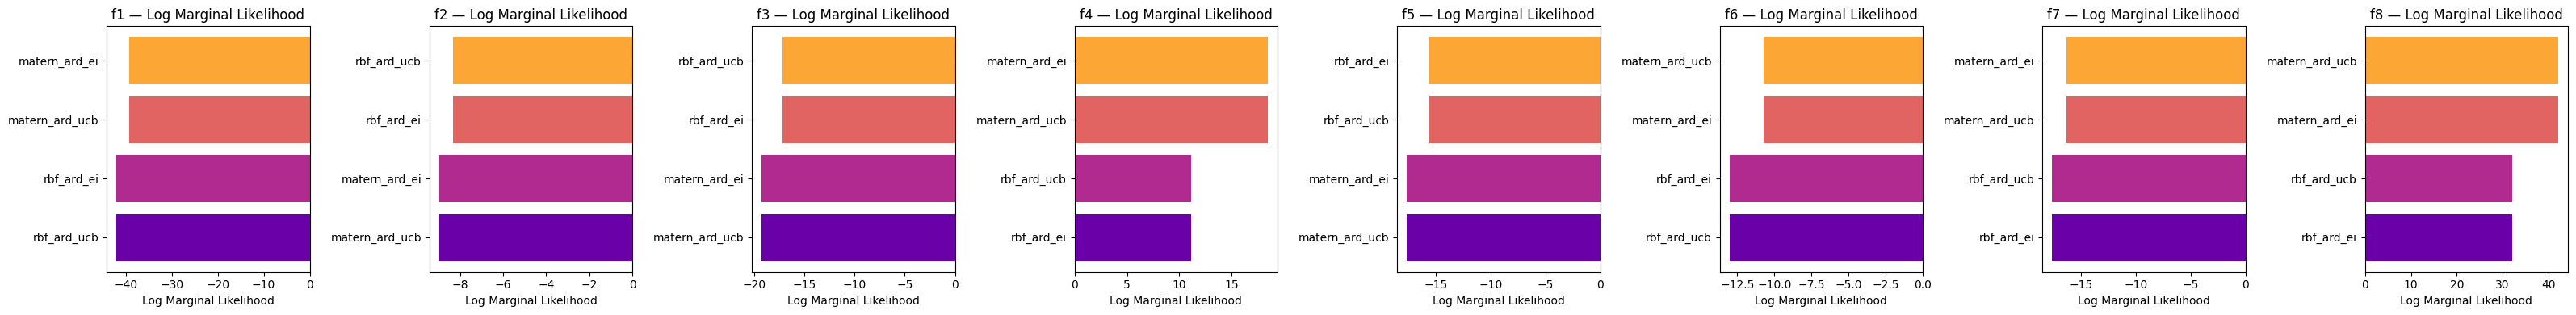

Saved to /home/claude/repo/runs/week_13/kernel_comparison.png


In [14]:
# ── KERNEL COMPARISON PLOT ─────────────────────────────────────
# For functions where multiple runs exist, compare log marginal likelihoods

df_multi = df_results[df_results.groupby('fn')['run_label'].transform('count') > 1]

if df_multi.empty:
    print('No multi-run functions to compare')
else:
    fns = sorted(df_multi['fn'].unique())
    n = len(fns)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4), squeeze=False)
    
    for ax, fn in zip(axes[0], fns):
        df_fn = df_multi[df_multi['fn'] == fn].sort_values('log_marginal_likelihood', ascending=True)
        colors = cm.plasma(np.linspace(0.2, 0.8, len(df_fn)))
        bars = ax.barh(df_fn['run_label'], df_fn['log_marginal_likelihood'], color=colors)
        ax.set_title(f'f{fn} — Log Marginal Likelihood')
        ax.set_xlabel('Log Marginal Likelihood')
        ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    
    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, 'kernel_comparison.png')
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved to {plot_path}')

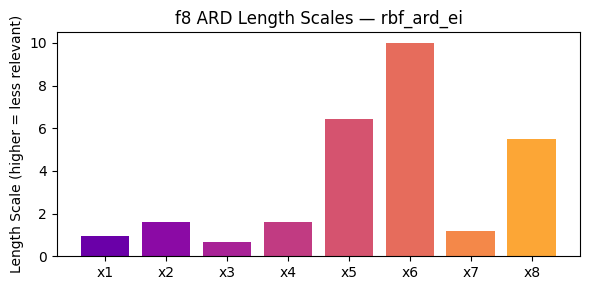

In [15]:
# ── ARD LENGTH SCALE PLOT ──────────────────────────────────────
# Shows per-dimension length scales for a chosen function and run
# Useful for identifying irrelevant dimensions

FN_TO_PLOT    = 8 # change as needed
LABEL_TO_PLOT = 'rbf_ard_ei'  # change as needed

def plot_ard_lengthscales(fn, run_label, data_dir=DATA_DIR, config_path=CONFIG_PATH,
                           results_dir=RESULTS_DIR):
    cfg = params[(params['fn'] == fn) & 
                 (params['run_label'] == run_label) & 
                 (params['week'] == CURRENT_WEEK)].iloc[0]
    
    X, y = load_function_data(fn, data_dir)
    d = X.shape[1]
    nu = float(cfg['nu']) if str(cfg['nu']) not in ('', 'nan') else 2.5
    log_tr = str(cfg['log_transform']).lower() == 'true'
    neg_floor = float(cfg['neg_floor']) if str(cfg['neg_floor']) not in ('', 'nan') else None
    
    y_t = transform_outputs(y, log_tr, neg_floor)
    kernel = build_kernel(d, cfg['kernel'], True, nu, fn=int(cfg['fn']))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=float(cfg['noise']),
                                   n_restarts_optimizer=N_RESTARTS, normalize_y=True)
    gp.fit(X, y_t)
    
    ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
    dims = [f'x{i+1}' for i in range(d)]
    colors = cm.plasma(np.linspace(0.2, 0.8, d))
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(dims, ls, color=colors)
    ax.set_ylabel('Length Scale (higher = less relevant)')
    ax.set_title(f'f{fn} ARD Length Scales — {run_label}')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f'ard_f{fn}_{run_label}.png'), dpi=120, bbox_inches='tight')
    plt.show()

plot_ard_lengthscales(FN_TO_PLOT, LABEL_TO_PLOT)

In [16]:
# === ADDED WEEK 4: Q² (predictive R²) diagnostic ===
# Leave-one-out cross-validation to assess GP generalisation quality.
# Q² close to R² → good generalisation. Q² << R² → overfitting.
# Q² < 0 → model worse than predicting the mean — strong warning sign.
#
# NOTE ON RESTARTS: the leave-one-out loop refits the GP once per observation,
# so its cost is (n_obs x restarts) fits per function. Q2_RESTARTS is set low
# here so the notebook runs end-to-end in a reasonable time for demonstration
# and reproduction — it is a fit-quality diagnostic, not part of the
# optimisation. The weekly submission runs used the full 50 restarts
# (N_RESTARTS above). Raise Q2_RESTARTS for a more stable Q2 estimate.
Q2_RESTARTS = 2

import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel, WhiteKernel

def compute_q2(fn, kernel_type='Matern', ARD=True, nu=2.5):
    """Compute leave-one-out Q² for a given function and kernel config."""
    df = load_function_df(fn)
    cols = [c for c in df.columns if c.startswith('x')]
    d = len(cols)
    X = df[cols].values
    y = df['output'].values

    # Use this function's actual configuration, so the diagnostic matches
    # the space the model was really fitted in (log10 for f1 and f5).
    cfg = get_fn_config(fn)
    y_t = transform_outputs(y, cfg)

    loo_preds = np.zeros(len(y_t))
    for i in range(len(y_t)):
        X_tr = np.delete(X, i, axis=0)
        y_tr = np.delete(y_t, i)
        kernel = build_kernel(d, kernel_type, ARD, nu, fn=fn)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                       n_restarts_optimizer=Q2_RESTARTS, normalize_y=True)
        gp.fit(X_tr, y_tr)
        loo_preds[i] = gp.predict(X[i:i+1])[0]

    ss_res = np.sum((y_t - loo_preds)**2)
    ss_tot = np.sum((y_t - y_t.mean())**2)
    q2 = 1 - ss_res / (ss_tot + 1e-12)

    # Also compute training R²
    kernel = build_kernel(d, kernel_type, ARD, nu, fn=fn)
    gp_full = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                        n_restarts_optimizer=10, normalize_y=True)
    gp_full.fit(X, y_t)
    y_pred_train = gp_full.predict(X)
    ss_res_train = np.sum((y_t - y_pred_train)**2)
    r2 = 1 - ss_res_train / (ss_tot + 1e-12)

    return q2, r2

print("Computing Q² (LOO cross-validation) for all functions...")
print(f"{'fn':>4}  {'n_obs':>6}  {'R²':>8}  {'Q²':>8}  {'gap':>8}  {'signal'}")
print("-" * 55)

for fn in range(1, 9):
    df = load_function_df(fn)
    n = len(df)
    try:
        q2, r2 = compute_q2(fn)
        gap = r2 - q2
        if q2 > 0.7:   signal = "✓ reliable"
        elif q2 > 0.3: signal = "~ moderate"
        elif q2 > 0.0: signal = "! weak"
        else:           signal = "✗ poor (overfit?)"
        print(f"f{fn:>1}   {n:>6}  {r2:>8.3f}  {q2:>8.3f}  {gap:>8.3f}  {signal}")
    except Exception as e:
        print(f"f{fn:>1}   {n:>6}  ERROR: {e}")


Computing Q² (LOO cross-validation) for all functions...
  fn   n_obs        R²        Q²       gap  signal
-------------------------------------------------------


f1       23     0.903    -0.253     1.157  ✗ poor (overfit?)


f2       23     0.987     0.700     0.287  ✓ reliable


f3       28     1.000     0.202     0.798  ! weak


f4       43     1.000     0.953     0.047  ✓ reliable


f5       33     1.000     0.674     0.326  ~ moderate


f6       33     0.997     0.605     0.392  ~ moderate


f7       43     1.000     0.861     0.139  ✓ reliable


f8       53     1.000     0.992     0.008  ✓ reliable


In [17]:
# === ADDED WEEK 4: SVR cross-check and Lasso dimension screening ===
# SVR: alternative surrogate — flags when GP and SVR disagree on optimum region
# Lasso: linear dimension screening — complements ARD length scale rankings

from sklearn.svm import SVR
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def svr_lasso_diagnostics(fn):
    """Fit SVR and Lasso alongside GP and compare dimension relevance."""
    df = load_function_df(fn)
    cols = [c for c in df.columns if c.startswith('x')]
    d = len(cols)
    X = df[cols].values
    y = df['output'].values

    cfg = {'fn': fn, 'kernel': 'Matern', 'ARD': True, 'nu': 2.5,
           'log_transform': False, 'neg_floor': -300, 'noise': 1e-6}
    y_t = transform_outputs(y, cfg)

    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    # SVR
    svr = SVR(kernel='rbf', C=10, epsilon=0.05)
    svr.fit(X_sc, y_t)
    svr_pred_train = svr.predict(X_sc)
    svr_r2 = 1 - np.sum((y_t - svr_pred_train)**2) / (np.sum((y_t - y_t.mean())**2) + 1e-12)

    # Lasso
    lasso = LassoCV(cv=min(5, len(y_t)-1), max_iter=5000)
    lasso.fit(X_sc, y_t)

    # GP ARD for comparison
    kernel = build_kernel(d, 'Matern', True, 2.5, fn=fn)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                   n_restarts_optimizer=10, normalize_y=True)
    gp.fit(X, y_t)
    ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)

    print(f"\nf{fn} ({d}D, {len(y_t)} obs)  SVR R²={svr_r2:.3f}")
    print(f"  {'dim':>5}  {'ARD ls':>8}  {'Lasso coef':>12}  {'relevance'}")
    print(f"  {'-'*40}")
    for i, col in enumerate(cols):
        lasso_c = lasso.coef_[i]
        ard_ls  = ls[i]
        # Both agree irrelevant
        if ard_ls > 4.0 and abs(lasso_c) < 0.05:
            rel = "likely irrelevant"
        elif ard_ls < 1.0 and abs(lasso_c) > 0.1:
            rel = "✓ active (both agree)"
        elif ard_ls > 4.0 and abs(lasso_c) > 0.1:
            rel = "! ARD says irrel, Lasso disagrees"
        elif ard_ls < 1.0 and abs(lasso_c) < 0.05:
            rel = "~ ARD active, Lasso says irrel"
        else:
            rel = "moderate"
        print(f"  {col:>5}  {ard_ls:>8.3f}  {lasso_c:>12.4f}  {rel}")

print("SVR + Lasso diagnostics for all functions:")
for fn in range(1, 9):
    try:
        svr_lasso_diagnostics(fn)
    except Exception as e:
        print(f"f{fn}: ERROR — {e}")


SVR + Lasso diagnostics for all functions:



f1 (2D, 23 obs)  SVR R²=-4.891
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     0.050        0.0000  ~ ARD active, Lasso says irrel
     x2     5.000        0.0000  likely irrelevant



f2 (2D, 23 obs)  SVR R²=0.948
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     0.100        0.1311  ✓ active (both agree)
     x2     5.000        0.0556  moderate



f3 (3D, 28 obs)  SVR R²=0.780
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     5.000        0.0000  likely irrelevant
     x2     1.161        0.0000  moderate
     x3     0.127        0.0000  ~ ARD active, Lasso says irrel



f4 (4D, 43 obs)  SVR R²=0.997
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     1.216       -3.1549  moderate
     x2     1.034       -2.3243  moderate
     x3     0.851       -1.7958  ✓ active (both agree)
     x4     1.021       -3.0753  moderate



f5 (4D, 33 obs)  SVR R²=-0.269
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     1.764      948.3837  moderate
     x2     1.330      667.8425  moderate
     x3     1.512     1012.7156  moderate
     x4     5.000      626.6233  ! ARD says irrel, Lasso disagrees



f6 (5D, 33 obs)  SVR R²=0.995
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     0.943       -0.1141  ✓ active (both agree)
     x2     1.157       -0.2167  moderate
     x3     1.957        0.1901  moderate
     x4     1.351        0.1103  moderate
     x5     2.620       -0.3406  moderate



f7 (6D, 43 obs)  SVR R²=0.995
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     0.721       -0.3624  ✓ active (both agree)
     x2     0.273        0.0845  moderate
     x3     0.864        0.0000  ~ ARD active, Lasso says irrel
     x4     0.385       -0.1407  ✓ active (both agree)
     x5     0.341       -0.1676  ✓ active (both agree)
     x6     0.539        0.0565  moderate



f8 (8D, 53 obs)  SVR R²=0.998
    dim    ARD ls    Lasso coef  relevance
  ----------------------------------------
     x1     3.348       -0.4915  moderate
     x2     4.775       -0.1139  ! ARD says irrel, Lasso disagrees
     x3     2.520       -0.6103  moderate
     x4     6.469       -0.0576  moderate
     x5    10.000        0.0000  likely irrelevant
     x6     4.984       -0.0000  likely irrelevant
     x7     3.374       -0.3135  moderate
     x8    10.000        0.0317  likely irrelevant


## 6.5 Surface Visualisations

In [18]:
# ── SURFACE VISUALISATIONS ────────────────────────────────────

# Colour scaling for the acquisition surfaces.
# EI is near zero across most of the domain once the incumbent best is high
# (at week 13, ~98% of the f4 space sits below 1% of the peak EI), so a linear
# scale renders almost everything as the bottom colour. A power-law norm
# spreads the low end of the range across the colour map, making the
# sub-peak structure visible while keeping the peak identifiable.
# Set ACQ_GAMMA = 1.0 for the raw linear scale.
ACQ_GAMMA = 0.3
# Generates pairwise EI-slice plots for each completed run and saves
# one PNG per (fn, run_label) into RESULTS_DIR.
#
# Pairs are ordered by ARD sensitivity (most sensitive dims first),
# capped at 6 panels. All other dims are fixed at the EI recommendation.
# When the run config used ARD=False (isotropic kernel), the GP is
# re-fitted with ARD=True for visualisation only — panel ordering reflects
# landscape sensitivity, not the actual kernel used. This is flagged in
# the plot title so results can be compared against ARD runs directly.
#
# Call: save_surface_plots()          → plots all runs in df_results
#       save_surface_plots(fn=3)       → only function 3
#       save_surface_plots(fn=3, run_label='rbf_ard_ei')  → single run

def _surface_for_run(fn, run_label, results_dir=RESULTS_DIR):
    """
    Fit GP for one (fn, run_label) and save a pairwise EI-slice figure.
    Returns the path to the saved PNG.
    """
    # ── load config row ──────────────────────────────────────
    cfg = params[
        (params['fn'] == fn) &
        (params['run_label'] == run_label) &
        (params['week'] == CURRENT_WEEK)
    ]
    if cfg.empty:
        print(f'  [skip] No config found for fn={fn}, run_label={run_label}')
        return None
    cfg = cfg.iloc[0]

    # ── load & transform data ────────────────────────────────
    X, y          = load_function_data(fn)
    d             = X.shape[1]
    input_cols    = [f'x{i+1}' for i in range(d)]
    nu            = float(cfg['nu']) if str(cfg['nu']) not in ('', 'nan') else 2.5
    log_tr        = str(cfg['log_transform']).lower() == 'true'
    neg_floor_val = float(cfg['neg_floor']) if str(cfg['neg_floor']) not in ('', 'nan') else None
    noise         = float(cfg['noise'])
    acq_fn        = cfg['acq_fn']
    config_ard    = str(cfg['ARD']).lower() == 'true'

    y_t    = transform_outputs(y, log_tr, neg_floor_val)
    y_best = float(np.max(y_t))

    # ── ARD GP — fitted with ARD=True solely to rank dimension pairs ──────
    ard_vis_only = not config_ard   # True when run config was isotropic
    gp_ard = GaussianProcessRegressor(
                 kernel=build_kernel(d, cfg['kernel'], True, nu, fn=int(cfg['fn'])), alpha=noise,
                 n_restarts_optimizer=N_RESTARTS, normalize_y=True)
    gp_ard.fit(X, y_t)

    # ── Config GP — exact run parameters; used for surface colours + star ──
    gp_cfg = GaussianProcessRegressor(
                 kernel=build_kernel(d, cfg['kernel'], config_ard, nu, fn=int(cfg['fn'])), alpha=noise,
                 n_restarts_optimizer=N_RESTARTS, normalize_y=True)
    gp_cfg.fit(X, y_t)
    x_rec = optimise_acquisition(acq_fn, gp_cfg, y_best, d)

    # ── ARD length scales from ARD vis-fit → sort dims ───────
    try:
        ls = np.atleast_1d(gp_ard.kernel_.k1.k2.length_scale)
    except AttributeError:
        ls = np.ones(d)
    sorted_dims = np.argsort(ls)   # smallest ls = most sensitive

    # ── build up to 6 most-informative pairs ─────────────────
    # Ranked by min(ls[a], ls[b]) so one dominant short-ls dimension
    # cannot monopolise all panels (e.g. x3 in every pair for high-D fns).
    all_pairs = []
    for a in range(d):
        for b in range(a + 1, d):
            all_pairs.append((int(a), int(b), min(ls[a], ls[b])))
    all_pairs.sort(key=lambda t: t[2])  # ascending: most sensitive pairs first
    pairs   = [(a, b) for a, b, _ in all_pairs[:min(6, len(all_pairs))]]
    n_pairs = len(pairs)

    # ── grid for contour plots ───────────────────────────────
    res  = 40
    g    = np.linspace(0, 1, res)
    G1, G2 = np.meshgrid(g, g)
    flat1, flat2 = G1.ravel(), G2.ravel()
    n_pts = res ** 2

    # ── layout ───────────────────────────────────────────────
    ncols = min(3, n_pairs)
    nrows = int(np.ceil(n_pairs / ncols)) if ncols > 0 else 1
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(5 * ncols, 4.5 * nrows),
                              squeeze=False)
    fig.subplots_adjust(wspace=0.4, hspace=0.55)

    for idx, (ia, ib) in enumerate(pairs):
        ax = axes[idx // ncols][idx % ncols]

        # build candidate grid — fix all other dims at recommendation
        grid        = np.tile(x_rec, (n_pts, 1))
        grid[:, ia] = flat1
        grid[:, ib] = flat2

        # Acquisition surface — config GP with actual run parameters
        mu_g, sigma_g = gp_cfg.predict(grid, return_std=True)
        sigma_g       = np.maximum(sigma_g, 1e-9)
        if acq_fn == 'EI':
            z        = (mu_g - y_best - 0.01) / sigma_g
            acq_grid = np.maximum((mu_g - y_best - 0.01) * norm.cdf(z)
                                   + sigma_g * norm.pdf(z), 0.0)
        else:  # UCB
            acq_grid = mu_g + 1.5 * sigma_g
            """ updated from 2.576 to 1.5 as of week 3 """

        # === ADDED: power-law colour scaling (see ACQ_GAMMA above) ===
        from matplotlib.colors import PowerNorm
        surf = acq_grid.reshape(res, res)
        lo = float(np.min(acq_grid)) if acq_fn == 'UCB' else 0.0
        hi = float(np.max(acq_grid))
        if hi <= lo:
            hi = lo + 1e-12
        # Filled contours (not pcolormesh) so the 40x40 evaluation grid is
        # smoothed rather than drawn as visible cells. Levels are bunched
        # towards the low end to match the power norm.
        colour_norm = PowerNorm(ACQ_GAMMA, vmin=lo, vmax=hi)
        levels = lo + (hi - lo) * np.linspace(0, 1, 31) ** (1.0 / ACQ_GAMMA)
        im = ax.contourf(G1, G2, surf, levels=levels, cmap='magma', norm=colour_norm)
        ax.scatter(X[:, ia], X[:, ib],
                   c='white', edgecolors='black', s=50, zorder=5, label='Obs')
        ax.scatter(x_rec[ia], x_rec[ib],
                   c='lime', edgecolors='black', s=180, marker='*', zorder=7, label='Next')
        plt.colorbar(im, ax=ax, label=f'{acq_fn} (power scale, gamma={ACQ_GAMMA:g})')

        fixed_str = ', '.join(f'{input_cols[k]}={x_rec[k]:.2f}'
                               for k in range(d) if k != ia and k != ib)
        ax.set_title(f'{acq_fn}: {input_cols[ia]}/{input_cols[ib]}\n({fixed_str})',
                     fontsize=8)
        ax.set_xlabel(input_cols[ia])
        ax.set_ylabel(input_cols[ib])
        ax.legend(fontsize=6, loc='upper right')

    # hide any spare panels
    for idx in range(n_pairs, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    # ── title — flag when ARD is vis-only ────────────────────
    ard_note = ' | ⚠ ARD ordering (vis only — run used isotropic)' if ard_vis_only else ''
    fig.suptitle(
        f'f{fn} — {run_label} ({d}D) | Week {CURRENT_WEEK}{ard_note}\n'
        f'{acq_fn} slices (pairs ranked by min ARD length scale)',
        fontsize=10, y=1.01
    )

    out_path = os.path.join(results_dir, f'surface_f{fn}_{run_label}_w{CURRENT_WEEK:02d}.png')
    plt.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'  Saved → {out_path}')
    return out_path


def save_surface_plots(fn=None, run_label=None, results_dir=RESULTS_DIR):
    """
    Generate and save surface plots for completed runs.
    fn         : int or None — if None, runs all functions in df_results
    run_label  : str or None — if None, runs all labels for the chosen fn(s)
    """
    df = pd.read_csv(os.path.join(results_dir, 'results.csv'))
    if fn is not None:
        df = df[df['fn'] == fn]
    if run_label is not None:
        df = df[df['run_label'] == run_label]

    if df.empty:
        print('No matching runs found in results.csv')
        return

    os.makedirs(results_dir, exist_ok=True)
    print(f'Generating surface plots for {len(df)} run(s)...')
    for _, row in df.iterrows():
        _surface_for_run(int(row['fn']), row['run_label'], results_dir)


print('Surface visualisation functions defined')
print("  → Call save_surface_plots() to plot all runs")
print("  → Or save_surface_plots(fn=3, run_label='rbf_ard_ei') for one run")
save_surface_plots()

Surface visualisation functions defined
  → Call save_surface_plots() to plot all runs
  → Or save_surface_plots(fn=3, run_label='rbf_ard_ei') for one run
Generating surface plots for 32 run(s)...


<Figure size 500x450 with 2 Axes>

  Saved → /home/claude/repo/runs/week_13/surface_f1_rbf_ard_ei_w13.png


<Figure size 500x450 with 2 Axes>

  Saved → /home/claude/repo/runs/week_13/surface_f1_matern_ard_ei_w13.png


...

<Figure size 1500x900 with 12 Axes>

  Saved → /home/claude/repo/runs/week_13/surface_f8_matern_ard_ucb_w13.png


<Figure size 1500x900 with 12 Axes>

  Saved → /home/claude/repo/runs/week_13/surface_f8_rbf_ard_ucb_w13.png


[figures written to runs/week_13/ — inline copies removed to keep the notebook
 small enough for GitHub to render; see the function pages in docs/ for them]

## 6.7 Slice Grid Visualisations

GP Mean μ and Uncertainty σ slice grids — primary visualisation for analysing the landscape and informing submission decisions.

- **2D**: single mean/sigma panel pair
- **3D**: 6×4 grid (11 slices of least-sensitive dim, mean left / sigma right, colourbar in slot 12)
- **4D**: two 5×5 grids (mean and sigma separately), axes = 2 most sensitive dims, rows/cols = next 2
- **5D+**: primary 5×5 (top 4 dims) + secondary check grid (substitute fixed dims into slices)

All 4 run recommendations shown as coloured stars on canonical matern_ard_ei GP surface.
Bucketing: [0,0.2), [0.2,0.4), [0.4,0.6), [0.6,0.8), [0.8,1.0] — each obs in exactly one panel.

In [19]:
# === ADDED WEEK 4: Slice grid helper functions ===
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.lines import Line2D

# Font sizes
FS_TITLE=9.5; FS_AXIS=9.0; FS_TICK=8.0; FS_ANNOT=8.5
FS_SUPTITLE=11.5; FS_LEGEND=10; FS_CB=9

# Fixed-boundary bucketing — each observation in exactly one panel
SLICE_VALS   = [0.1, 0.3, 0.5, 0.7, 0.9]
BUCKET_EDGES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.001]

def get_bucket(val):
    """Assign a value to exactly one slice bucket."""
    for i, (lo, hi) in enumerate(zip(BUCKET_EDGES[:-1], BUCKET_EDGES[1:])):
        if lo <= val < hi:
            return SLICE_VALS[i]
    return SLICE_VALS[-1]

STAR_COLORS = {
    'matern_ard_ei':  'lime',
    'matern_ard_ucb': 'cyan',
    'rbf_ard_ei':     'white',
    'rbf_ard_ucb':    'orange',
}

def get_run_recs(fn, results_dir=RESULTS_DIR):
    """Load all 4 run recommendations for a function from results.csv."""
    results_path = os.path.join(results_dir, 'results.csv')
    if not os.path.exists(results_path):
        return {}
    df = pd.read_csv(results_path)
    df_fn = df[df['fn'] == fn]
    recs = {}
    for _, row in df_fn.iterrows():
        coords = [float(v) for v in str(row['recommendation']).split('-')]
        rl = row['run_label']
        recs[rl] = {'x': np.array(coords), 'color': STAR_COLORS.get(rl, 'grey')}
    return recs

def fit_canonical_gp(fn):
    """Fit canonical GP (matern ARD, ls cap) for slice visualisation."""
    df = load_function_df(fn)
    cols = [c for c in df.columns if c.startswith('x')]
    d = len(cols)
    X = df[cols].values
    y = df['output'].values
    # Use this function's actual configuration, so the diagnostic matches
    # the space the model was really fitted in (log10 for f1 and f5).
    cfg = get_fn_config(fn)
    y_t = transform_outputs(y, cfg)
    kernel = build_kernel(d, 'Matern', True, 2.5, fn=fn)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                   n_restarts_optimizer=10, normalize_y=True)
    gp.fit(X, y_t)
    ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
    order = np.argsort(ls)
    return gp, X, y, y_t, cols, d, ls, order

def add_obs_to_panel(ax, X_sl, y_sl, ax_dim1, ax_dim2, mu_vmin, mu_vmax):
    """Plot observations on a panel, coloured by output value."""
    if len(X_sl) == 0:
        return
    ax.scatter(X_sl[:,ax_dim1], X_sl[:,ax_dim2],
               c=np.clip(y_sl, mu_vmin, mu_vmax),
               cmap='plasma', vmin=mu_vmin, vmax=mu_vmax,
               edgecolors='white', linewidths=0.9, s=90, zorder=5)
    for xi, yi_ax, oi in zip(X_sl[:,ax_dim1], X_sl[:,ax_dim2], y_sl):
        txt = ax.annotate(f'{oi:.3f}', (xi, yi_ax),
                          xytext=(4,4), textcoords='offset points',
                          fontsize=FS_ANNOT, color='white', fontweight='bold', zorder=6)
        txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground='black')])

def add_stars_to_panel(ax, recs, s1, s2, ax_dim1, ax_dim2,
                        bucket_s1, bucket_s2):
    """Add run recommendation stars to panel if they belong there."""
    has_star = False
    for rl, rec in recs.items():
        if bucket_s1[rl] == s1 and bucket_s2[rl] == s2:
            ax.scatter(rec['x'][ax_dim1], rec['x'][ax_dim2],
                       c=rec['color'], edgecolors='black',
                       s=180, marker='*', zorder=7, linewidths=0.9)
            has_star = True
    if has_star:
        for spine in ax.spines.values():
            spine.set_edgecolor('yellow'); spine.set_linewidth(2.0)
    return has_star

def add_legend(fig, recs):
    """Add star colour legend to figure."""
    legend_elements = [
        Line2D([0],[0], marker='*', color='w', markerfacecolor=v['color'],
               markeredgecolor='black', markersize=11, label=k, linewidth=0)
        for k, v in recs.items()
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4,
               fontsize=FS_LEGEND, framealpha=0.9, bbox_to_anchor=(0.45, -0.02))

print("Slice grid helper functions loaded ✓")
print(f"  Bucketing: {list(zip(BUCKET_EDGES[:-1], BUCKET_EDGES[1:]))} → {SLICE_VALS}")


Slice grid helper functions loaded ✓
  Bucketing: [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.001)] → [0.1, 0.3, 0.5, 0.7, 0.9]


In [20]:
# === ADDED WEEK 4: Main slice grid plotting function ===

def plot_slice_grid(fn, save=True, results_dir=RESULTS_DIR):
    """
    Generate GP mean + sigma slice grid for a function.
    - 2D: single mean/sigma panel pair
    - 3D: 6x4 grid (11 slices, mean left / sigma right)
    - 4D+: two 5x5 grids (mean and sigma separately)
    - 5D+: primary 5x5 + secondary check grid
    """
    gp, X, y, y_t, cols, d, ls, order = fit_canonical_gp(fn)
    recs = get_run_recs(fn, results_dir)

    dim_names = cols
    res = 40
    g = np.linspace(0, 1, res)

    # ── 2D: single panel pair ─────────────────────────────────────
    if d == 2:
        G1, G2 = np.meshgrid(g, g)
        grid = np.column_stack([G1.ravel(), G2.ravel()])
        mu, sigma = gp.predict(grid, return_std=True)
        mu_grid = mu.reshape(res, res)
        sig_grid = sigma.reshape(res, res)

        mu_vmin = np.percentile(np.concatenate([mu, y_t]), 2)
        mu_vmax = np.percentile(np.concatenate([mu, y_t]), 98)
        sig_vmax = np.percentile(sigma, 98)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5.8))
        fig.subplots_adjust(wspace=0.35)

        for ax_idx, (surf, cmap, vmin, vmax, title) in enumerate([
            (mu_grid,  'plasma',  mu_vmin, mu_vmax,  'GP Mean μ'),
            (sig_grid, 'viridis', 0,       sig_vmax, 'GP Uncertainty σ'),
        ]):
            ax = axes[ax_idx]
            ax.contourf(G1, G2, np.clip(surf, vmin, vmax), levels=30, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.contour(G1, G2, np.clip(surf, vmin, vmax), levels=8, colors='white', alpha=0.12, linewidths=0.4)
            plt.colorbar(plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap),
                         ax=ax, label=title)
            add_obs_to_panel(ax, X, y_t, 0, 1, mu_vmin, mu_vmax)
            for rl, rec in recs.items():
                ax.scatter(rec['x'][0], rec['x'][1], c=rec['color'],
                           edgecolors='black', s=220, marker='*', zorder=7)
            ax.set_xlabel(cols[0], fontsize=FS_AXIS)
            ax.set_ylabel(cols[1], fontsize=FS_AXIS)
            ax.tick_params(labelsize=FS_TICK)
            ax.set_title(title, fontsize=FS_TITLE)

        axes[2].set_visible(False)
        add_legend(fig, recs)
        ls_str = ', '.join([f'{cols[i]}={ls[i]:.3f}' for i in range(d)])
        fig.suptitle(f'f{fn} — {d}D | Week {CURRENT_WEEK}  |  GP Mean & Uncertainty  |  ls cap  |  {len(y)} obs\n{ls_str}',
                     fontsize=FS_SUPTITLE, y=1.02)
        if save:
            path = os.path.join(results_dir, f'slice_f{fn}_w{CURRENT_WEEK:02d}.png')
            plt.savefig(path, dpi=130, bbox_inches='tight')
            print(f"Saved: {path}")
        plt.show(); plt.close()
        return

    # ── 3D: 6x4 grid (11 slices) ─────────────────────────────────
    if d == 3:
        ax_dim1, ax_dim2 = order[0], order[1]
        sl_dim  = order[2]
        ax_label, ab_label = cols[ax_dim1], cols[ax_dim2]
        sl_label = cols[sl_dim]

        GA, GB = np.meshgrid(g, g)
        flatA, flatB = GA.ravel(), GB.ravel()
        slice_vals_3d = np.round(np.arange(0.0, 1.01, 0.1), 1)

        all_mu, all_sigma = [], []
        for sv in slice_vals_3d:
            grid = np.zeros((len(flatA), 3))
            grid[:, ax_dim1] = flatA; grid[:, ax_dim2] = flatB; grid[:, sl_dim] = sv
            mu, sigma = gp.predict(grid, return_std=True)
            all_mu.append(mu); all_sigma.append(sigma)

        mu_vmin = np.percentile(np.concatenate(all_mu + [y_t]), 2)
        mu_vmax = np.percentile(np.concatenate(all_mu + [y_t]), 98)
        sig_vmax = np.percentile(np.concatenate(all_sigma), 98)

        obs_bucket = np.array([get_bucket(v) for v in X[:, sl_dim]])
        snap_tol = 0.05

        rec_sl = {rl: round(round(rec['x'][sl_dim]/0.1)*0.1, 1)
                  for rl, rec in recs.items()}

        nrows, ncols = 4, 6
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.6, nrows*3.2))
        fig.subplots_adjust(wspace=0.32, hspace=0.48)

        for idx, sv in enumerate(slice_vals_3d):
            row, col = divmod(idx, 3)
            for half, (all_vals, cmap, vmin, vmax) in enumerate([
                (all_mu, 'plasma', mu_vmin, mu_vmax),
                (all_sigma, 'viridis', 0, sig_vmax),
            ]):
                ax = axes[row][col + half*3]
                surf = np.clip(all_vals[idx].reshape(res,res), vmin, vmax)
                ax.contourf(GA, GB, surf, levels=25, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.contour(GA, GB, surf, levels=6, colors='white', alpha=0.12, linewidths=0.4)

                lo = sv - snap_tol if sv > 0.0 else 0.0
                hi = sv + snap_tol if sv < 1.0 else 1.0
                mask = (X[:, sl_dim] >= lo) & (X[:, sl_dim] < hi)
                add_obs_to_panel(ax, X[mask], y_t[mask], ax_dim1, ax_dim2, mu_vmin, mu_vmax)

                has_star = False
                for rl, rec in recs.items():
                    if abs(sv - rec_sl.get(rl, -1)) < 1e-9:
                        ax.scatter(rec['x'][ax_dim1], rec['x'][ax_dim2],
                                   c=rec['color'], edgecolors='black',
                                   s=180, marker='*', zorder=7)
                        has_star = True
                if has_star:
                    for spine in ax.spines.values():
                        spine.set_edgecolor('yellow'); spine.set_linewidth(2.0)

                prefix = 'μ' if half==0 else 'σ'
                ax.set_title(f'{prefix}  {sl_label}={sv:.1f}  (n={mask.sum()})', fontsize=FS_TITLE, pad=3)
                ax.set_xlabel(ax_label, fontsize=FS_AXIS)
                ax.set_ylabel(ab_label, fontsize=FS_AXIS)
                ax.tick_params(labelsize=FS_TICK)

        # Colourbar panels
        for cidx, (cmap, vmin, vmax, label) in enumerate([
            ('plasma', mu_vmin, mu_vmax, 'GP Mean μ'),
            ('viridis', 0, sig_vmax, 'GP Std Dev σ'),
        ]):
            axes[3][2+cidx*3].set_visible(False)
            p = axes[3][2+cidx*3].get_position()
            cb_ax = fig.add_axes([p.x0+0.01, p.y0+0.05, p.width*0.35, p.height*0.80])
            ColorbarBase(cb_ax, cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax), label=label)
            cb_ax.tick_params(labelsize=FS_CB)

        add_legend(fig, recs)
        ls_str = ', '.join([f'{cols[i]}={ls[i]:.3f}' for i in range(d)])
        fig.suptitle(f'f{fn} — {d}D | Week {CURRENT_WEEK}  |  μ (left) & σ (right)  |  Slices: {sl_label}\n{ls_str}',
                     fontsize=FS_SUPTITLE, y=1.01)
        if save:
            path = os.path.join(results_dir, f'slice_f{fn}_w{CURRENT_WEEK:02d}.png')
            plt.savefig(path, dpi=120, bbox_inches='tight')
            print(f"Saved: {path}")
        plt.show(); plt.close()
        return

    # ── 4D+: 5x5 grids ───────────────────────────────────────────
    ax_dim1, ax_dim2 = order[0], order[1]
    sl_dim1, sl_dim2 = order[2], order[3]
    fixed_dims = list(order[4:])

    ax_label, ab_label = cols[ax_dim1], cols[ax_dim2]
    sl1_label, sl2_label = cols[sl_dim1], cols[sl_dim2]

    # Fix remaining dims at median recommendation value
    fixed_vals = {}
    for fd in fixed_dims:
        vals = [rec['x'][fd] for rec in recs.values() if fd < len(rec['x'])]
        fixed_vals[fd] = np.median(vals) if vals else 0.5

    GA, GB = np.meshgrid(g, g)
    flatA, flatB = GA.ravel(), GB.ravel()

    obs_b_s1 = np.array([get_bucket(v) for v in X[:, sl_dim1]])
    obs_b_s2 = np.array([get_bucket(v) for v in X[:, sl_dim2]])

    all_mu, all_sigma = [], []
    for s1 in SLICE_VALS:
        for s2 in SLICE_VALS:
            grid = np.zeros((len(flatA), d))
            grid[:, ax_dim1] = flatA; grid[:, ax_dim2] = flatB
            grid[:, sl_dim1] = s1;    grid[:, sl_dim2] = s2
            for fd in fixed_dims:
                grid[:, fd] = fixed_vals[fd]
            mu, sigma = gp.predict(grid, return_std=True)
            all_mu.append(mu); all_sigma.append(sigma)

    mu_vmin = np.percentile(np.concatenate(all_mu + [y_t]), 2)
    mu_vmax = np.percentile(np.concatenate(all_mu + [y_t]), 98)
    sig_vmax = np.percentile(np.concatenate(all_sigma), 98)

    rec_b_s1 = {rl: get_bucket(rec['x'][sl_dim1]) for rl, rec in recs.items() if sl_dim1 < len(rec['x'])}
    rec_b_s2 = {rl: get_bucket(rec['x'][sl_dim2]) for rl, rec in recs.items() if sl_dim2 < len(rec['x'])}

    fixed_str = ', '.join([f'{cols[fd]}={fixed_vals[fd]:.3f}' for fd in fixed_dims])
    ls_str = ', '.join([f'{cols[i]}={ls[i]:.3f}' for i in range(d)])

    def make_5x5(surface_vals, cmap, vmin, vmax, cb_label, title_suffix, filename):
        fig, axes = plt.subplots(5, 6, figsize=(6*3.2, 5*3.1))
        fig.subplots_adjust(wspace=0.32, hspace=0.55)
        for ri, s1 in enumerate(SLICE_VALS):
            for ci, s2 in enumerate(SLICE_VALS):
                ax = axes[ri][ci]
                idx = ri*5+ci
                surf = np.clip(surface_vals[idx].reshape(res,res), vmin, vmax)
                ax.contourf(GA, GB, surf, levels=25, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.contour(GA, GB, surf, levels=6, colors='white', alpha=0.12, linewidths=0.4)

                mask = (obs_b_s1 == s1) & (obs_b_s2 == s2)
                add_obs_to_panel(ax, X[mask], y_t[mask], ax_dim1, ax_dim2, mu_vmin, mu_vmax)
                add_stars_to_panel(ax, recs, s1, s2, ax_dim1, ax_dim2, rec_b_s1, rec_b_s2)

                ax.set_title(f'{sl1_label}={s1:.1f}, {sl2_label}={s2:.1f}  (n={mask.sum()})',
                             fontsize=FS_TITLE, pad=3)
                ax.set_xlabel(ax_label, fontsize=FS_AXIS)
                ax.set_ylabel(ab_label, fontsize=FS_AXIS)
                ax.tick_params(labelsize=FS_TICK)

        for ri in range(5):
            axes[ri][5].set_visible(False)
        p0 = axes[0][5].get_position(); p4 = axes[4][5].get_position()
        cb_ax = fig.add_axes([p0.x0+0.005, p4.y0, p0.width*0.35, p0.y1-p4.y0])
        ColorbarBase(cb_ax, cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax), label=cb_label)
        cb_ax.tick_params(labelsize=FS_CB)
        add_legend(fig, recs)
        fig.suptitle(
            f'f{fn} — {d}D | Week {CURRENT_WEEK}  |  {title_suffix}  |  ls cap\n'
            f'Axes: {ax_label}/{ab_label}  |  Rows: {sl1_label}  |  Cols: {sl2_label}  |  Fixed: {fixed_str}\n{ls_str}',
            fontsize=FS_SUPTITLE, y=1.01)
        if save:
            plt.savefig(filename, dpi=120, bbox_inches='tight')
            print(f"Saved: {filename}")
        plt.show(); plt.close()

    make_5x5(all_mu, 'plasma', mu_vmin, mu_vmax, 'GP Mean μ', 'GP Mean μ',
             os.path.join(results_dir, f'slice_f{fn}_mean_w{CURRENT_WEEK:02d}.png'))
    make_5x5(all_sigma, 'viridis', 0, sig_vmax, 'GP Std Dev σ', 'GP Uncertainty σ',
             os.path.join(results_dir, f'slice_f{fn}_sigma_w{CURRENT_WEEK:02d}.png'))

    # ── Secondary check for 5D+ ───────────────────────────────────
    if d >= 5 and len(fixed_dims) >= 1:
        print(f"\nBuilding secondary check grid (substituting fixed dims into slices)...")
        # Swap: fix the primary slice dims, substitute fixed dim into slices
        sec_sl_dim1 = fixed_dims[0]
        sec_sl_dim2 = fixed_dims[1] if len(fixed_dims) > 1 else sl_dim1
        sec_fixed = {sl_dim1: fixed_vals.get(sl_dim1, 0.5),
                     sl_dim2: fixed_vals.get(sl_dim2, 0.5)}
        for fd in fixed_dims[2:]:
            sec_fixed[fd] = fixed_vals[fd]

        sec_b_s1 = np.array([get_bucket(v) for v in X[:, sec_sl_dim1]])
        sec_b_s2 = np.array([get_bucket(v) for v in X[:, sec_sl_dim2]])
        sec_rec_b_s1 = {rl: get_bucket(rec['x'][sec_sl_dim1]) for rl, rec in recs.items()
                        if sec_sl_dim1 < len(rec['x'])}
        sec_rec_b_s2 = {rl: get_bucket(rec['x'][sec_sl_dim2]) for rl, rec in recs.items()
                        if sec_sl_dim2 < len(rec['x'])}

        sec_mu = []
        for s1 in SLICE_VALS:
            for s2 in SLICE_VALS:
                grid = np.zeros((len(flatA), d))
                grid[:, ax_dim1] = flatA; grid[:, ax_dim2] = flatB
                grid[:, sec_sl_dim1] = s1; grid[:, sec_sl_dim2] = s2
                for fd, fv in sec_fixed.items():
                    grid[:, fd] = fv
                mu, _ = gp.predict(grid, return_std=True)
                sec_mu.append(mu)

        sec_fixed_str = ', '.join([f'{cols[k]}={v:.3f}' for k, v in sec_fixed.items()])

        fig, axes = plt.subplots(5, 6, figsize=(6*3.2, 5*3.1))
        fig.subplots_adjust(wspace=0.32, hspace=0.55)
        for ri, s1 in enumerate(SLICE_VALS):
            for ci, s2 in enumerate(SLICE_VALS):
                ax = axes[ri][ci]
                idx = ri*5+ci
                surf = np.clip(sec_mu[idx].reshape(res,res), mu_vmin, mu_vmax)
                ax.contourf(GA, GB, surf, levels=25, cmap='plasma', vmin=mu_vmin, vmax=mu_vmax)
                ax.contour(GA, GB, surf, levels=6, colors='white', alpha=0.12, linewidths=0.4)

                mask = (sec_b_s1 == s1) & (sec_b_s2 == s2)
                add_obs_to_panel(ax, X[mask], y_t[mask], ax_dim1, ax_dim2, mu_vmin, mu_vmax)
                add_stars_to_panel(ax, recs, s1, s2, ax_dim1, ax_dim2, sec_rec_b_s1, sec_rec_b_s2)

                ax.set_title(f'{cols[sec_sl_dim1]}={s1:.1f}, {cols[sec_sl_dim2]}={s2:.1f}  (n={mask.sum()})',
                             fontsize=FS_TITLE, pad=3)
                ax.set_xlabel(ax_label, fontsize=FS_AXIS); ax.set_ylabel(ab_label, fontsize=FS_AXIS)
                ax.tick_params(labelsize=FS_TICK)

        for ri in range(5): axes[ri][5].set_visible(False)
        p0 = axes[0][5].get_position(); p4 = axes[4][5].get_position()
        cb_ax = fig.add_axes([p0.x0+0.005, p4.y0, p0.width*0.35, p0.y1-p4.y0])
        ColorbarBase(cb_ax, cmap='plasma', norm=Normalize(vmin=mu_vmin, vmax=mu_vmax), label='GP Mean μ')
        cb_ax.tick_params(labelsize=FS_CB)
        add_legend(fig, recs)
        fig.suptitle(
            f'f{fn} — {d}D SECONDARY CHECK | Week {CURRENT_WEEK}  |  GP Mean μ\n'
            f'Axes: {ax_label}/{ab_label}  |  Rows: {cols[sec_sl_dim1]} (sub)  |  Cols: {cols[sec_sl_dim2]} (sub)  |  Fixed: {sec_fixed_str}',
            fontsize=FS_SUPTITLE, y=1.01)
        if save:
            path = os.path.join(results_dir, f'slice_f{fn}_secondary_w{CURRENT_WEEK:02d}.png')
            plt.savefig(path, dpi=120, bbox_inches='tight')
            print(f"Saved: {path}")
        plt.show(); plt.close()


# ── Run slice grids ───────────────────────────────────────────────
# plot_slice_grid(1)   # 2D
# plot_slice_grid(3)   # 3D
# plot_slice_grid(5)   # 4D

# Run all:
for fn in RUN_FUNCTIONS if RUN_FUNCTIONS != 'all' else range(1, 9):
    print(f"\n=== f{fn} slice grid ===")
    plot_slice_grid(fn)



=== f1 slice grid ===


Saved: /home/claude/repo/runs/week_13/slice_f1_w13.png


<Figure size 1500x580 with 5 Axes>


=== f2 slice grid ===


Saved: /home/claude/repo/runs/week_13/slice_f2_w13.png


...

<Figure size 1920x1550 with 31 Axes>


Building secondary check grid (substituting fixed dims into slices)...


Saved: /home/claude/repo/runs/week_13/slice_f8_secondary_w13.png


<Figure size 1920x1550 with 31 Axes>

[figures written to runs/week_13/ — inline copies removed to keep the notebook
 small enough for GitHub to render; see the function pages in docs/ for them]

## 7. Append New Results (run after portal returns outputs)

In [21]:
# ── APPEND RESULTS FROM PORTAL FILES ──────────────────────────
# Save inputs.txt and outputs.txt from the portal into runs/week_NN/
# then run this cell to append all 8 functions to the data CSVs

import ast
import re

def _parse_bracketed_lists(text):
    """
    Parse a text blob containing one or more top-level Python list literals,
    robust to numpy's multi-line wrapping of long arrays (e.g. f8's 8-dim
    arrays get wrapped across lines, which breaks naive line-by-line or
    single-shot ast.literal_eval parsing).

    Strategy: strip 'array(...)' wrappers, collapse all whitespace/newlines
    to single spaces (safe since the wrapping is purely cosmetic), then
    track bracket depth to recover each top-level list independently —
    this works regardless of how many weeks' worth of lines are in the file.
    """
    # Strip array([...]) -> [...], and np.float64(...) -> ... (handles either file type)
    clean = re.sub(r'array\((\[.*?\])\)', r'\1', text, flags=re.DOTALL)
    clean = re.sub(r'np\.float64\(([^)]+)\)', r'\1', clean)
    flat  = re.sub(r'\s+', ' ', clean)

    results, depth, start = [], 0, None
    for i, ch in enumerate(flat):
        if ch == '[':
            if depth == 0:
                start = i
            depth += 1
        elif ch == ']':
            depth -= 1
            if depth == 0 and start is not None:
                results.append(ast.literal_eval(flat[start:i+1]))
                start = None
    return results


def load_portal_files(results_dir=RESULTS_DIR, week_index=-1):
    """
    Read inputs.txt and outputs.txt from the week's results folder.
    The portal appends one line per week to each file, so this returns
    the week at `week_index` (default -1 = most recent / last line).
    """
    inputs_path  = os.path.join(results_dir, 'inputs.txt')
    outputs_path = os.path.join(results_dir, 'outputs.txt')

    with open(inputs_path, 'r') as f:
        inputs_raw = f.read()
    with open(outputs_path, 'r') as f:
        outputs_raw = f.read()

    all_inputs  = _parse_bracketed_lists(inputs_raw)
    all_outputs = _parse_bracketed_lists(outputs_raw)

    if not all_inputs or not all_outputs:
        raise ValueError('No parseable rows found in inputs.txt / outputs.txt')

    inputs  = all_inputs[week_index]
    outputs = all_outputs[week_index]

    return inputs, outputs


def append_portal_results(results_dir=RESULTS_DIR, data_dir=DATA_DIR):
    inputs, outputs = load_portal_files(results_dir)

    assert len(inputs) == len(outputs) == 8, \
        f"Expected 8 functions, got {len(inputs)} inputs and {len(outputs)} outputs"

    for fn_idx, (x_new, y_new) in enumerate(zip(inputs, outputs), start=1):
        x_new = list(x_new)
        append_result(fn_idx, x_new, float(y_new))
        print(f'  f{fn_idx}: appended x={[round(v,6) for v in x_new]}, y={y_new}')

    print(f'\nDone — {len(inputs)} functions updated.')


# ── RUN ────────────────────────────────────────────────────────
inputs_path  = os.path.join(RESULTS_DIR, 'inputs.txt')
outputs_path = os.path.join(RESULTS_DIR, 'outputs.txt')

if os.path.exists(inputs_path) and os.path.exists(outputs_path):
    append_portal_results()
else:
    print('No result files yet — add inputs.txt and outputs.txt to', RESULTS_DIR)

No result files yet — add inputs.txt and outputs.txt to /home/claude/repo/runs/week_13
